In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prachi13/customer-analytics/Train.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/kaggle/input/datasets/prachi13/customer-analytics/Train.csv')
df.head()



,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [5]:
df.shape

(10999, 12)

In [6]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [7]:
missing_values=df.isnull().sum()
duplicate_items=df.duplicated().sum()
print(f"Missing Values:\n {missing_values}")
print(f"Total Duplicate items: {duplicate_items}")


Missing Values:
 ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64
Total Duplicate items: 0


In [8]:
df.nunique()

ID                     10999
Warehouse_block            5
Mode_of_Shipment           3
Customer_care_calls        6
Customer_rating            5
Cost_of_the_Product      215
Prior_purchases            8
Product_importance         3
Gender                     2
Discount_offered          65
Weight_in_gms           4034
Reached.on.Time_Y.N        2
dtype: int64

We have 3 categorial datas:
Mode of Shipment:3 categories
Warehouse_block:3 categories
Product Importance:3 categories



we need to apply encoding to the categorial features:
for warehouse block and mode of shipment we can use one hot encoding ,for product importance it hass order so we can use ordinal encoding

<Axes: >

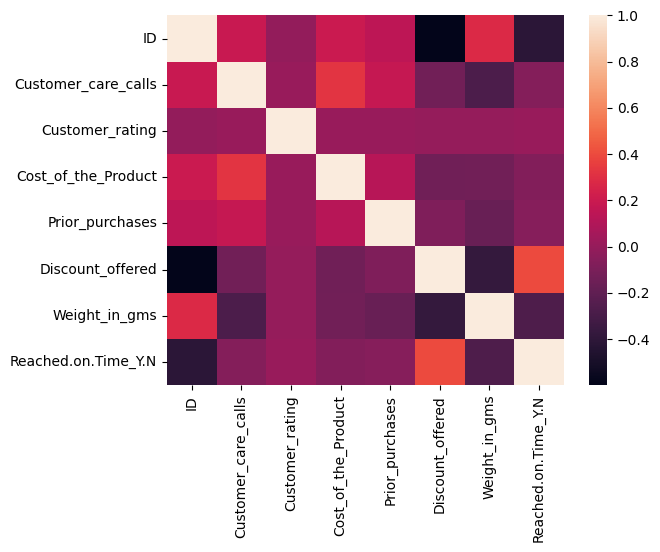

In [9]:
sns.heatmap(df.corr(numeric_only=True))

<Axes: xlabel='Reached.on.Time_Y.N', ylabel='count'>

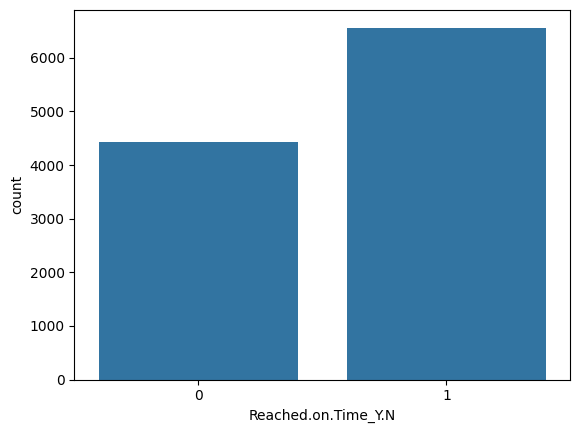

In [10]:
sns.countplot(data=df,x='Reached.on.Time_Y.N')

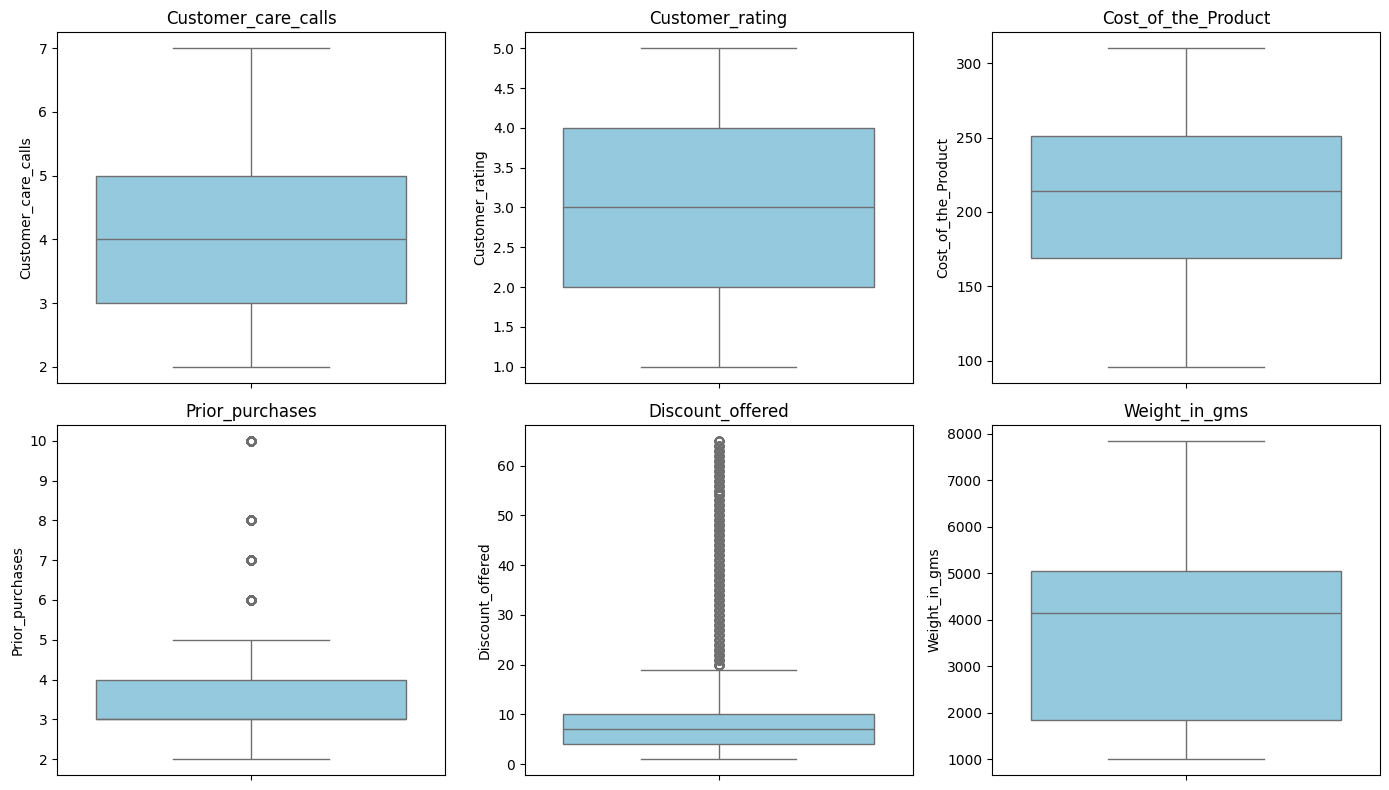

In [11]:
numeric_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 
                'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols,1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

So the prior purchases has some outliers and dicount_offered has concentration of outliers.So i dont need to remove these outliers when dealing with Tree based models as they naturally resist extreme calused  but gradient based algorithms(Logistic regression,SVM ,KNN) are sensitive to them.

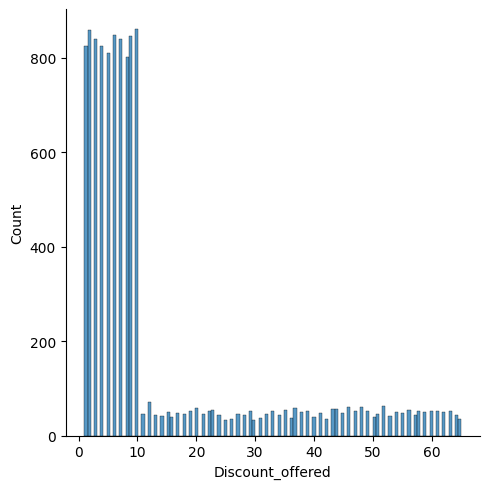

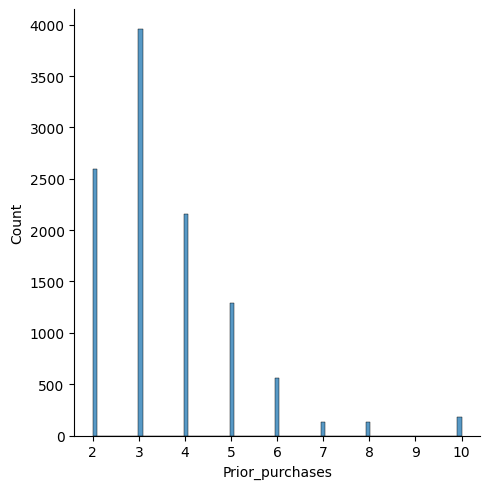

In [12]:
sns.displot(df['Discount_offered']) 
sns.displot(df['Prior_purchases']) 

In [13]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

**first performing the train-test split then applying column transformer(fit on train and transform on test).**

doing transformation first leads to data leakage as transformer would calculate encoding categories, frequency statistics, or scaling parameters using the entire dataset;including information from your test set.

In [14]:
X = df.drop(columns=['Reached.on.Time_Y.N', 'ID'])
y = 1 - df['Reached.on.Time_Y.N']   #changinng so that 1 means:delay and 0 means: on time as we are predicting 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [15]:
from sklearn.compose import ColumnTransformer

In [16]:
importance_order = ['low', 'medium', 'high']

#ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=[importance_order]), ['Product_importance']),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False), ['Warehouse_block', 'Mode_of_Shipment', 'Gender'])
    ],
    remainder='passthrough'  #Keeps numeric columns untouched for now
)

In [17]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [18]:
X_train_encoded.shape

(7039, 14)

In [19]:
dataframe_encoded=pd.DataFrame(X_train_encoded)

just want to peek at the new preprocessed table

In [20]:
dataframe_encoded.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,1.0,153.0,2.0,51.0,1841.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,3.0,205.0,2.0,58.0,2187.0
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,5.0,4.0,267.0,5.0,9.0,1113.0
3,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,5.0,140.0,4.0,2.0,4636.0
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,4.0,260.0,5.0,5.0,1952.0


In [21]:
from sklearn.preprocessing import StandardScaler

#Scaling columns
num_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

# Updating ColumnTransformer to include scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=[importance_order]), ['Product_importance']),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False), ['Warehouse_block', 'Mode_of_Shipment', 'Gender']),
        ('scaler', StandardScaler(), num_cols)  # Scale numerical columns directly here
    ],
    remainder='drop'  # Drop any leftover columns not specified
)

# Fiting on training data and transforming both sets
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [22]:
dataframe_encoded=pd.DataFrame(X_train_encoded)

In [23]:
dataframe_encoded.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.932162,-1.410433,-1.193161,-1.031916,2.346779,-1.107691
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.932162,-0.002600,-0.108895,-1.031916,2.782391,-0.895641
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.823185,0.701316,1.183883,0.937622,-0.266895,-1.553854
3,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.809835,1.405233,-1.464227,0.281109,-0.702507,0.605257
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.054488,0.701316,1.037924,0.937622,-0.515816,-1.039663


**RandomForest Pipeline**

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

#a clean pipeline with lower tree depth to prevent overfitting
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1))
])


rf_pipeline.fit(X_train, y_train)


y_pred = rf_pipeline.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[708 605]
 [131 756]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.54      0.66      1313
           1       0.56      0.85      0.67       887

    accuracy                           0.67      2200
   macro avg       0.70      0.70      0.67      2200
weighted avg       0.73      0.67      0.66      2200



changing depth in rf

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Build a clean pipeline with lower tree depth to prevent overfitting
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])


rf_pipeline.fit(X_train, y_train)

#Evaluate
y_pred = rf_pipeline.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[722 591]
 [182 705]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.55      0.65      1313
           1       0.54      0.79      0.65       887

    accuracy                           0.65      2200
   macro avg       0.67      0.67      0.65      2200
weighted avg       0.70      0.65      0.65      2200



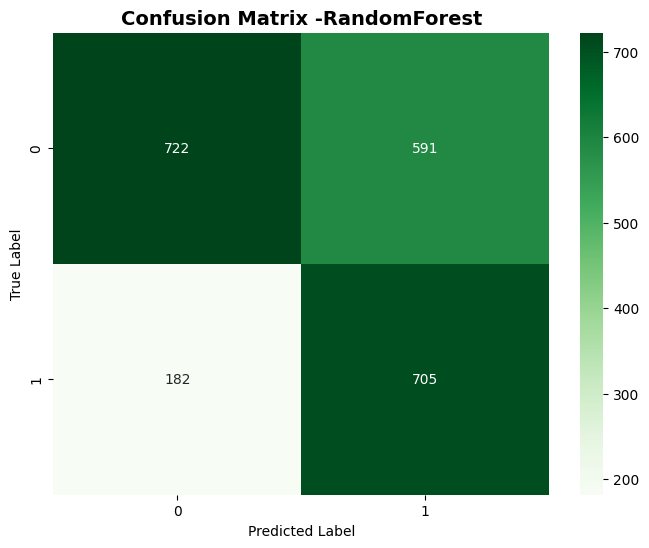

In [26]:
plt.figure(figsize=(8, 6))
cm_adv = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Greens', cbar=True)
plt.title('Confusion Matrix -RandomForest', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

**XGBoost Pipeline**

In [27]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.54      0.65      1313
           1       0.55      0.83      0.66       887

    accuracy                           0.66      2200
   macro avg       0.69      0.69      0.66      2200
weighted avg       0.72      0.66      0.66      2200



In [28]:
from sklearn.metrics import precision_score, recall_score

from sklearn.metrics import (
    precision_recall_curve,
    classification_report,
    f1_score
)

y_val_prob = xgb_pipeline.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.20, 0.71, 0.01)

results = []

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    results.append({
        'threshold': threshold,
        'precision': precision_score(y_val, y_val_pred),
        'recall': recall_score(y_val, y_val_pred),
        'f1': f1_score(y_val, y_val_pred)
    })

threshold_results = pd.DataFrame(results)

threshold_results.sort_values(
    'f1',
    ascending=False
).head(10)

,threshold,precision,recall,f1
4,0.24,0.573984,0.994366,0.727835
5,0.25,0.573984,0.994366,0.727835
12,0.32,0.576606,0.985915,0.727651
13,0.33,0.577337,0.983099,0.727462
3,0.23,0.573517,0.994366,0.727460
2,0.22,0.573517,0.994366,0.727460
6,0.26,0.573637,0.992958,0.727179
14,0.34,0.577465,0.981690,0.727178
11,0.31,0.575062,0.987324,0.726801
1,0.21,0.572587,0.994366,0.726711


In [29]:
valid_thresholds = threshold_results[
    threshold_results['recall'] >= 0.80
]

best_threshold = valid_thresholds.sort_values(
    'precision',
    ascending=False
).iloc[0]['threshold']

print("Selected threshold:", best_threshold)

Selected threshold: 0.5100000000000002


In [30]:
y_test_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.80      0.56      0.66      1313
           1       0.55      0.79      0.65       887

    accuracy                           0.66      2200
   macro avg       0.68      0.68      0.66      2200
weighted avg       0.70      0.66      0.66      2200



In [31]:
feature_names = (
    xgb_pipeline
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importances = (
    xgb_pipeline
    .named_steps['classifier']
    .feature_importances_
)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(
    'importance',
    ascending=False
)

feature_importance.head(15)

,feature,importance
12,scaler__Discount_offered,0.656849
11,scaler__Prior_purchases,0.074695
13,scaler__Weight_in_gms,0.046938
1,onehot__Warehouse_block_B,0.028464
10,scaler__Cost_of_the_Product,0.025060
7,onehot__Gender_M,0.021129
2,onehot__Warehouse_block_C,0.020056
6,onehot__Mode_of_Shipment_Ship,0.019803
8,scaler__Customer_care_calls,0.019617
9,scaler__Customer_rating,0.019074


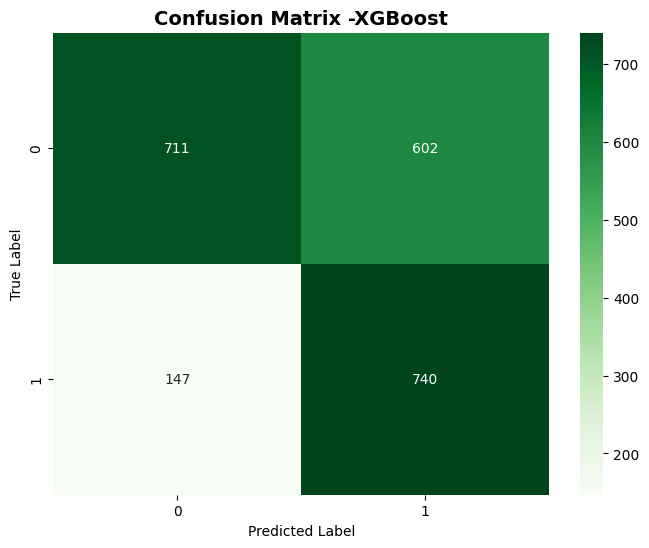

In [32]:
plt.figure(figsize=(8, 6))
cm_adv = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Greens', cbar=True)
plt.title('Confusion Matrix -XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [33]:

from sklearn.metrics import roc_auc_score
y_probs = xgb_pipeline.predict_proba(X_test)[:, 1]


#auc_rf=roc_auc_score(y_test, y_probs)
auc_XGB=roc_auc_score(y_test, y_probs)
print(f"auc_roc for XGB {auc_XGB}")

y_probs_rf = rf_pipeline.predict_proba(X_test)[:, 1]
auc_rf=roc_auc_score(y_test, y_probs_rf)
print(f"auc_roc for rf {auc_rf}")


auc_roc for XGB 0.7193020793710627
auc_roc for rf 0.713806347246467


In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 4, 5],
    'classifier__learning_rate': [0.01, 0.05],
    'classifier__scale_pos_weight': [0.8, 1.0, 1.2]  # Adjusts weighting between classes
}

grid_search = GridSearchCV(xgb_pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best ROC-AUC:", grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

Best ROC-AUC: 0.7487352280940197
Best Params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 1.2}


In [35]:
from sklearn.model_selection import GridSearchCV

# Define multiple scoring metrics
scoring = {
    'ROC_AUC': 'roc_auc',
    'F1': 'f1',
    'PR_AUC': 'average_precision'
}

grid_search = GridSearchCV(
    xgb_pipeline, 
    param_grid, 
    cv=5, 
    scoring=scoring, 
    refit='PR_AUC',  # Selects the best model based on PR-AUC
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# View scores across metrics for the best estimator
results = grid_search.cv_results_
best_index = grid_search.best_index_

print("Best Parameters:", grid_search.best_params_)
print(f"Mean PR-AUC:  {results['mean_test_PR_AUC'][best_index]:.4f}")
print(f"Mean ROC-AUC: {results['mean_test_ROC_AUC'][best_index]:.4f}")
print(f"Mean F1-Score:{results['mean_test_F1'][best_index]:.4f}")

Best Parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 1.2}
Mean PR-AUC:  0.5761
Mean ROC-AUC: 0.7487
Mean F1-Score:0.7117


In [36]:
from lightgbm import LGBMClassifier

lgb_pipeline = Pipeline(steps=[
     ('preprocessor', preprocessor),
     ('classifier', LGBMClassifier(n_estimators=150, learning_rate=0.03, max_depth=4, random_state=42))
 ])

lgb_pipeline.fit(X_train, y_train)

y_pred_lgb = lgb_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 2839, number of negative: 4200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001598 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 572
[LightGBM] [Info] Number of data points in the train set: 7039, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.403324 -> initscore=-0.391633
[LightGBM] [Info] Start training from score -0.391633
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [37]:
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score

# Dictionary of trained models
models = {
    "Random Forest": rf_pipeline,
    "XGBoost (GridSearch Best)": grid_search.best_estimator_,
    "LightGBM": lgb_pipeline,
}

# Iterate through models and evaluate metrics on X_test, y_test
for name, model in models.items():
    # Predict probabilities for AUC metrics
    y_probs = model.predict_proba(X_test)[:, 1]

    # Predict class labels for F1-score
    y_preds = model.predict(X_test)

    # Calculate metrics
    pr_auc = average_precision_score(y_test, y_probs)
    roc_auc = roc_auc_score(y_test, y_probs)
    f1 = f1_score(y_test, y_preds)

    print(f"--- {name} ---")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")

--- Random Forest ---
PR-AUC:    0.5458
ROC-AUC:   0.7138
F1-Score:  0.6459

--- XGBoost (GridSearch Best) ---
PR-AUC:    0.5547
ROC-AUC:   0.7291
F1-Score:  0.6970

--- LightGBM ---
PR-AUC:    0.5372
ROC-AUC:   0.7124
F1-Score:  0.6811



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [38]:
#for final xgb-pipeline-> mixing validation set and test set
import joblib

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from xgboost import XGBClassifier

# 1. Re-merge X_train and X_val to use all available training data
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

# 2. Extract best parameters from GridSearch and set up the final model pipeline
best_params = {
    k.replace("classifier__", ""): v
    for k, v in grid_search.best_params_.items()
}

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(**best_params, random_state=42, n_jobs=-1),
        ),
    ]
)

# 3. Fit pipeline on full training data (X_train + X_val)
final_pipeline.fit(X_train_full, y_train_full)

# 4. Tune Decision Threshold based on Business Cost Weights
# Define custom costs (adjust these numbers according to real business impact)
COST_FALSE_NEGATIVE = 10.0  # Cost of missing a delayed shipment (e.g., unhappy customer, refund)
COST_FALSE_POSITIVE = 3.0  # Cost of false alarm (e.g., unnecessary notification/voucher)

# Get predicted probabilities on training data to optimize threshold
y_probs_train = final_pipeline.predict_proba(X_train_full)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
best_threshold = 0.5
min_total_cost = float("inf")

for t in thresholds:
    preds = (y_probs_train >= t).astype(int)
    cm = confusion_matrix(y_train_full, preds)

    # cm structure: [[TN, FP], [FN, TP]]
    fp = cm[0][1]
    fn = cm[1][0]

    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)

    if total_cost < min_total_cost:
        min_total_cost = total_cost
        best_threshold = t

print(f"Optimal Decision Threshold based on business cost: {best_threshold:.2f}")

# 5. Evaluate tuned threshold on unseen Test Set (X_test)
y_probs_test = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_probs_test >= best_threshold).astype(int)

print("\n--- Test Set Evaluation (Custom Threshold) ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))



Optimal Decision Threshold based on business cost: 0.37

--- Test Set Evaluation (Custom Threshold) ---
Confusion Matrix:
[[598 715]
 [  6 881]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.46      0.62      1313
           1       0.55      0.99      0.71       887

    accuracy                           0.67      2200
   macro avg       0.77      0.72      0.67      2200
weighted avg       0.81      0.67      0.66      2200



In [39]:
from sklearn.metrics import average_precision_score, roc_auc_score

# Generate predicted probabilities for the positive class (Delayed Shipments)
y_probs_test = final_pipeline.predict_proba(X_test)[:, 1]

# Compute Area Under Precision-Recall Curve (PR-AUC)
pr_auc = average_precision_score(y_test, y_probs_test)

# Compute Area Under Receiver Operating Characteristic Curve (ROC-AUC)
roc_auc = roc_auc_score(y_test, y_probs_test)

# Display results
print(f"New PR-AUC:  {pr_auc:.4f}")
print(f"New ROC-AUC: {roc_auc:.4f}")

New PR-AUC:  0.5566
New ROC-AUC: 0.7312


In [40]:
import joblib

#save the complete pipeline (Preprocessor + Model)
joblib.dump(final_pipeline, 'xgboost_shipping_delay_model.pkl')

#save the optimal decision threshold
joblib.dump(best_threshold, 'model_threshold.pkl')

print("Model pipeline and decision threshold saved successfully!")

Model pipeline and decision threshold saved successfully!
